In [50]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [51]:
df = pd.read_csv('drug200.csv')

In [52]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [53]:
df.isna().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [54]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [55]:
df.shape

(200, 6)

In [56]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Age: 57 unique values
Sex: 2 unique values
BP: 3 unique values
Cholesterol: 2 unique values
Na_to_K: 198 unique values
Drug: 5 unique values


In [57]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [58]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [59]:
for col in categorical_cols:
    print(f"{col}: {df[col].value_counts()}")
    print("\n")

Sex: Sex
M    104
F     96
Name: count, dtype: int64


BP: BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64


Cholesterol: Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64


Drug: Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64




In [60]:
def plot_categorical_distribution(df, categorical_cols):
    for col in categorical_cols:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col)
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)
        plt.show()

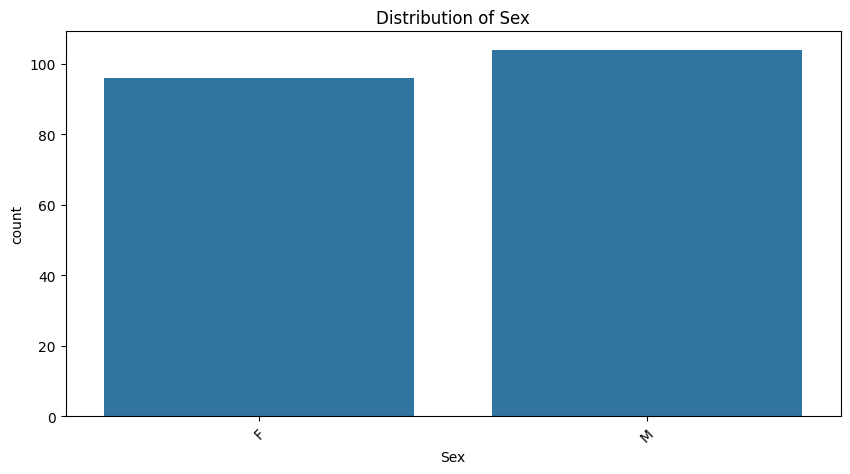

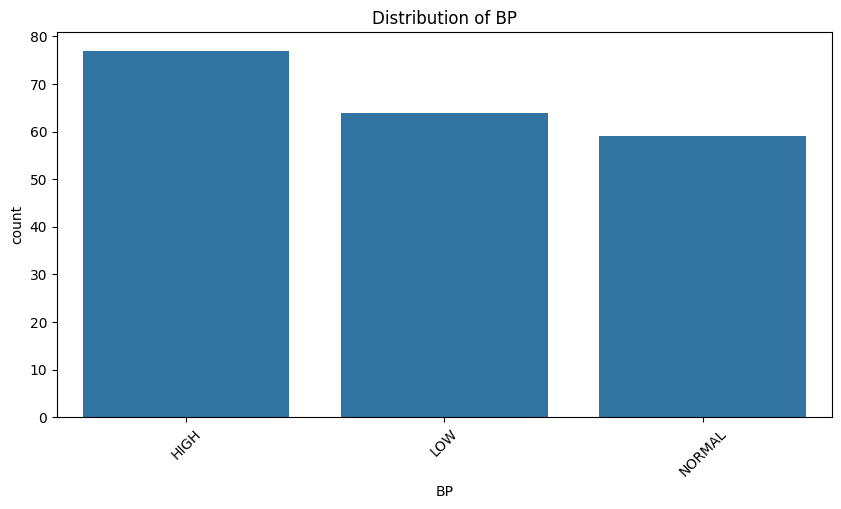

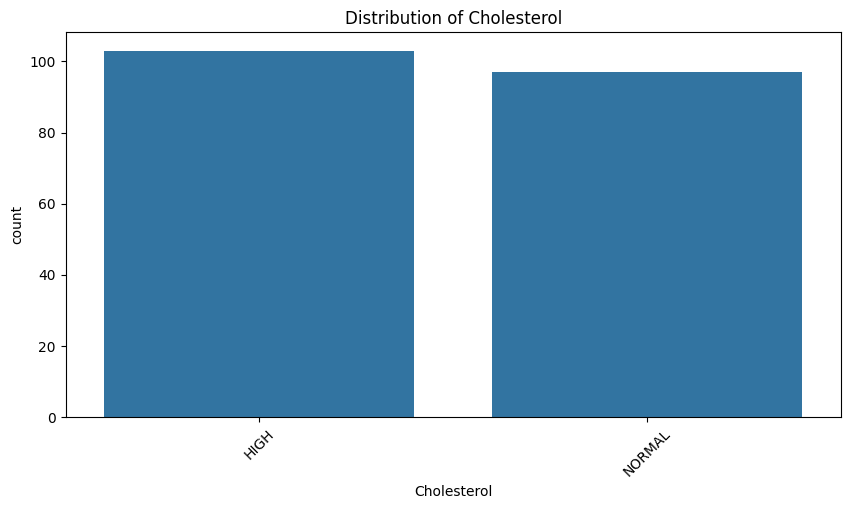

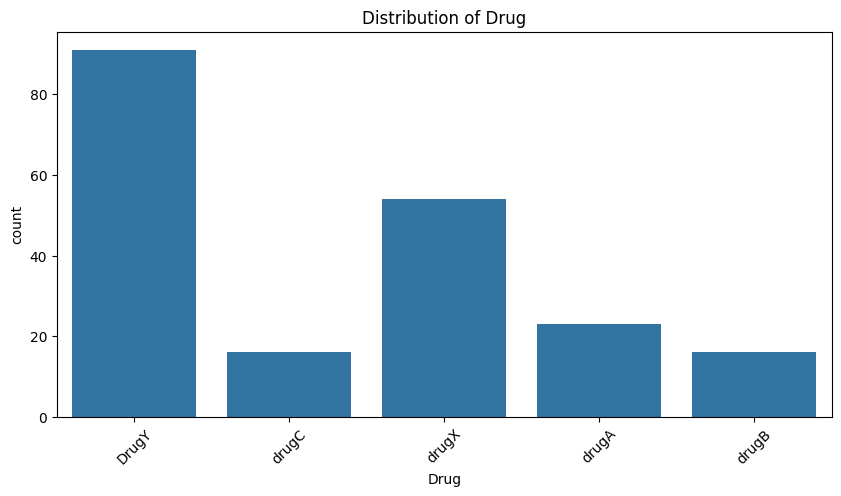

In [61]:
plot_categorical_distribution(df, categorical_cols)

In [62]:
def plot_numerical_distribution(df, numerical_cols):
    for col in numerical_cols:
        plt.figure(figsize=(10, 5))
        sns.histplot(data=df, x=col, kde=True,bins=30)
        plt.title(f'Distribution of {col}')
        plt.show()

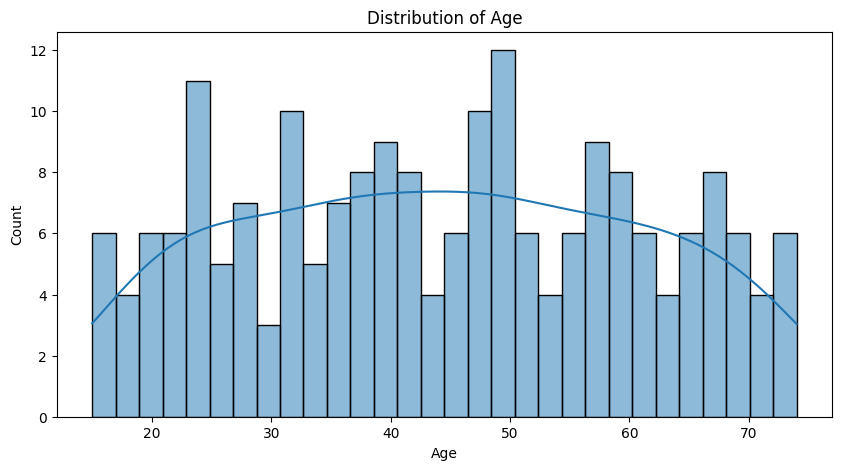

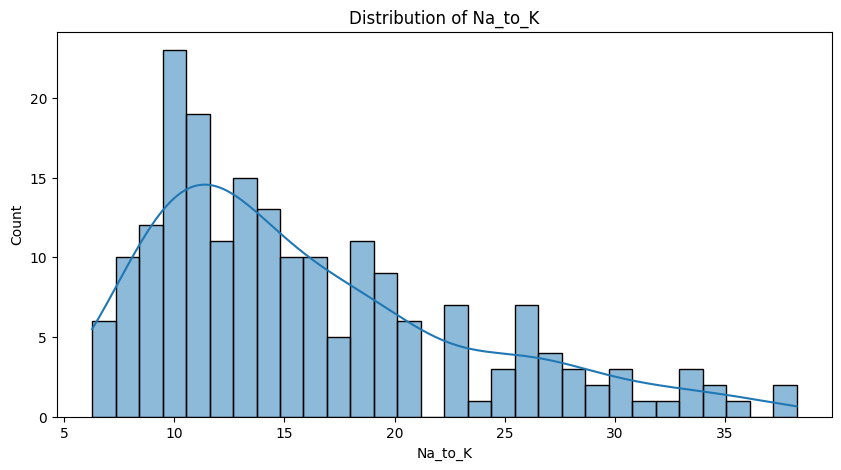

In [63]:
plot_numerical_distribution(df, numerical_cols)

<Axes: >

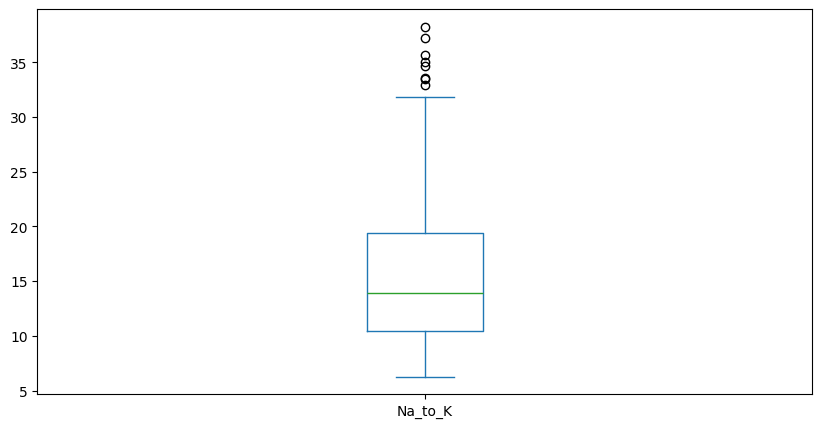

In [64]:
df['Na_to_K'].plot.box(figsize=(10, 5))

In [65]:
def winsorize_column(df, column, lower_quantile=0.05, upper_quantile=0.95):
    lower_bound = df[column].quantile(lower_quantile)
    upper_bound = df[column].quantile(upper_quantile)
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

In [66]:
winsorize_column(df, 'Na_to_K')

<Axes: >

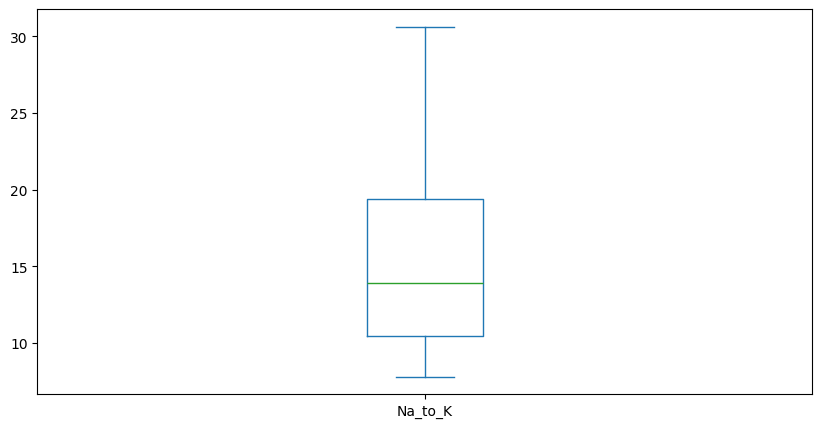

In [67]:
df['Na_to_K'].plot.box(figsize=(10, 5))

In [68]:
from sklearn.preprocessing import LabelEncoder


In [69]:
def encode_categorical_columns(df, categorical_cols):
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    return label_encoders

In [70]:
encode_categorical_columns(df, categorical_cols)

{'Sex': LabelEncoder(),
 'BP': LabelEncoder(),
 'Cholesterol': LabelEncoder(),
 'Drug': LabelEncoder()}

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler = StandardScaler()

In [74]:
scaled_df = pd.DataFrame(scaler.fit_transform(df[numerical_cols]), columns=numerical_cols)

In [75]:
df = scaled_df.join(df[categorical_cols])

In [76]:
df

,Age,Na_to_K,Sex,BP,Cholesterol,Drug
0,-1.291591,1.407424,0,0,0,0
1,0.162699,-0.422865,1,1,0,3
2,0.162699,-0.867525,1,1,0,3
3,-0.988614,-1.213223,0,2,0,4
4,1.011034,0.315997,0,1,0,0
...,...,...,...,...,...,...
195,0.708057,-0.650643,0,1,0,3
196,-1.715759,-0.585116,1,1,0,3
197,0.465676,-0.900364,1,2,0,4
198,-1.291591,-0.284496,1,2,1,4
